# Análises relacionadas ao ciclo de vida dos inscritos

## 1. Carregamento de libs e definição de funções

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlalchemy
import numpy as np

def import_query(path):
    with open(path, 'r') as open_file:
        query = open_file.read()
    return query

## 2. Carregamento da base de dados

In [2]:
query = import_query("life_cycle_grouped.sql")
engine_analytical = sqlalchemy.create_engine("sqlite:///../../data/analytics/database.db")

df = pd.read_sql(query, engine_analytical)

df = df.pivot(index="dtRef", columns="descLifeCycle", values="qtdCliente")
df = df.fillna(0)

df.head()

descLifeCycle,01-CURIOSO,02-FIEL,03-TURISTA,04-DESENCANTADA,06-RECONQUISTADO,07-REBORN
dtRef,,,,,,
2024-04-30,19.0,167.0,174.0,165.0,7.0,10.0
2024-05-31,17.0,154.0,81.0,143.0,10.0,21.0
2024-06-30,40.0,165.0,77.0,105.0,14.0,19.0
2024-07-31,49.0,125.0,80.0,126.0,15.0,18.0
2024-08-31,22.0,151.0,73.0,88.0,9.0,28.0


## 3. Construção do gráfico de barras empilhadas

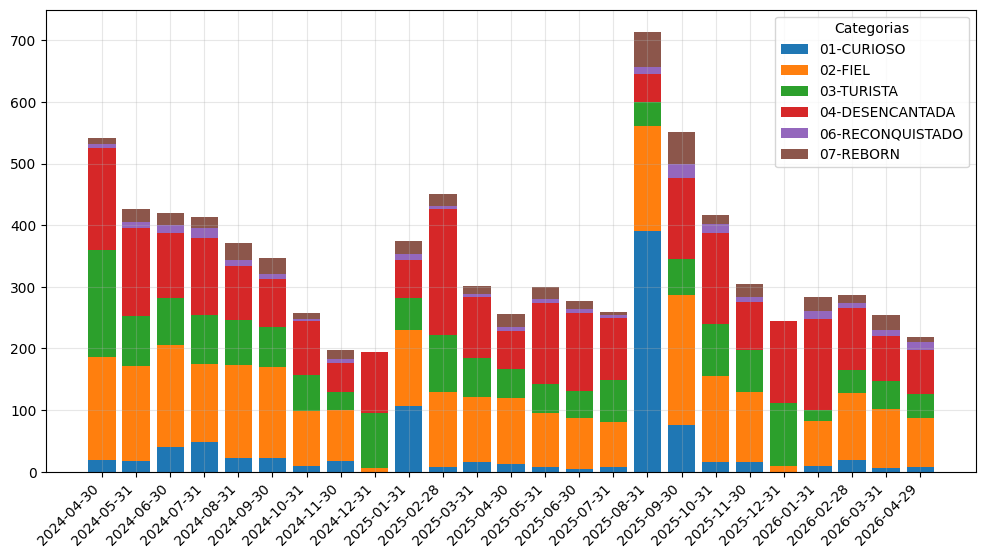

In [3]:
linhas = df.index
colunas = df.columns
x = np.arange(len(df))
bottom = np.zeros(len(df))

plt.figure(figsize=(12, 6))

for col in colunas:
    plt.bar(x, df[col], bottom=bottom, label=col)
    bottom += df[col]

plt.xticks(x, linhas)
plt.legend(loc="upper right", title="Categorias")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.show()